In [1]:
import pandas as pd

#reading the csv file

df = pd.read_csv('population_total.csv')
#read dataframe
df

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09
...,...,...,...
4180,United States,1965.0,1.997337e+08
4181,United States,1960.0,1.867206e+08
4182,United States,1955.0,1.716853e+08
4183,India,1960.0,4.505477e+08


1 Making a pivot table

.pivot() returns reshaped dataframe organized by given index /column values

In [3]:
#dropping null values 
#dropna return a copy 
df.dropna(inplace=True)

In [5]:
#making a pivot table
df_pivot = df.pivot(index='year', columns= 'country' ,values='population')

In [7]:
#selecting some countries
df_pivot_filter = df_pivot[['United States','India','China','Brazil']]




In [8]:
#showing pivot table
df_pivot_filter

country,United States,India,China,Brazil
year,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,162019896.0


In [44]:
#importing matplotlib
import matplotlib.pyplot as plt

2 Lineplot 

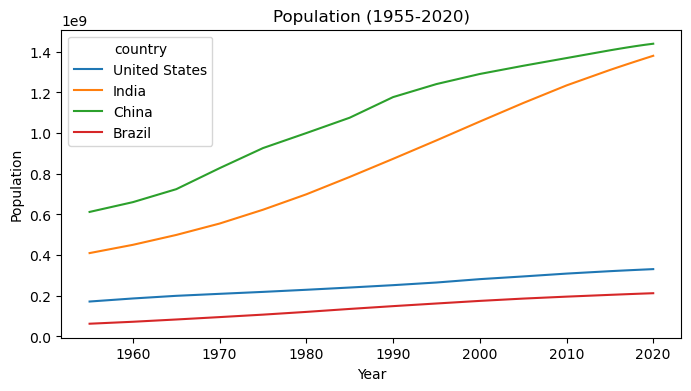

In [45]:
df_pivot_filter.plot(kind='line',xlabel='Year', ylabel='Population', title='Population (1955-2020)',
                    figsize=(8,4))

#save plot
plt.savefig('testimage.png')
#show plot
plt.show()

In [46]:
df_pivot_filter.to_excel('pivot_table.xlsx')

3 Barplot

3.1 Single Barplot

In [14]:
#selecting only one year (2020)
df_pivot_2020 = df_pivot_filter [df_pivot_filter.index.isin([2020.0])]

In [15]:
#showing new dataframe
df_pivot_2020

country,United States,India,China,Brazil
year,,,,
2020.0,331002651.0,1.380004e+09,1.439324e+09,212559417.0


In [17]:
# transpose data from rows to col and viceversa
df_pivot_2020T = df_pivot_2020.T

<Axes: title={'center': 'Population 2020'}, xlabel='Year', ylabel='Population'>

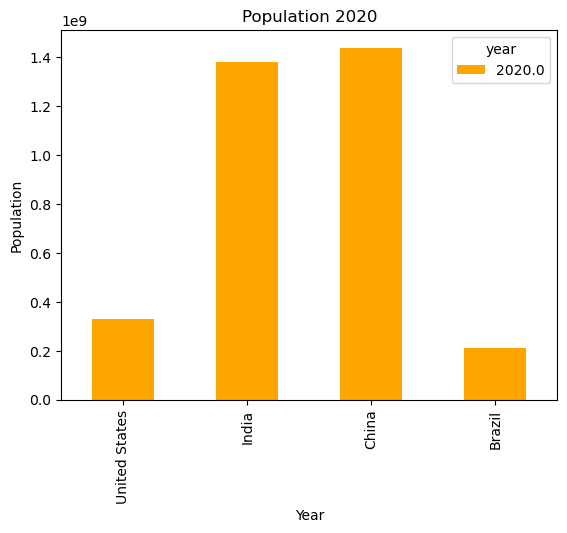

In [19]:
#making barplot
df_pivot_2020T.plot(kind='bar', color='orange', xlabel='Year' , ylabel="Population" , title='Population 2020')

3.2 Barplot grouped by n vairables

In [23]:
#selecting a few years 

df_pivot_sample = df_pivot_filter [df_pivot_filter.index.isin([1980 ,1990 , 2000,2010, 2020])]
df_pivot_sample

country,United States,India,China,Brazil
year,,,,
1980.0,229476354.0,6.989528e+08,1.000089e+09,120694009.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,149003223.0
2000.0,281710909.0,1.056576e+09,1.290551e+09,174790340.0
2010.0,309011475.0,1.234281e+09,1.368811e+09,195713635.0
2020.0,331002651.0,1.380004e+09,1.439324e+09,212559417.0


<Axes: title={'center': 'Population '}, xlabel='Year', ylabel='Population'>

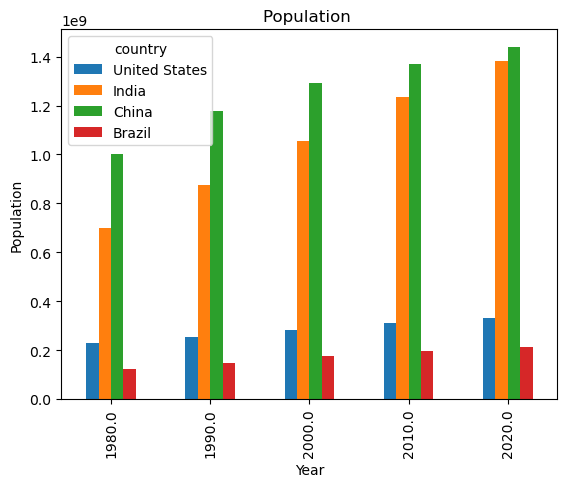

In [25]:
#making grouped barplot 
df_pivot_sample.plot(kind='bar', xlabel='Year' , ylabel="Population" , title='Population ')

4 Piechart

In [28]:
#changing column name
df_pivot_2020T.rename(columns={2020:'2020'},inplace=True)


<Axes: title={'center': 'Population in 2020%'}, ylabel='2020'>

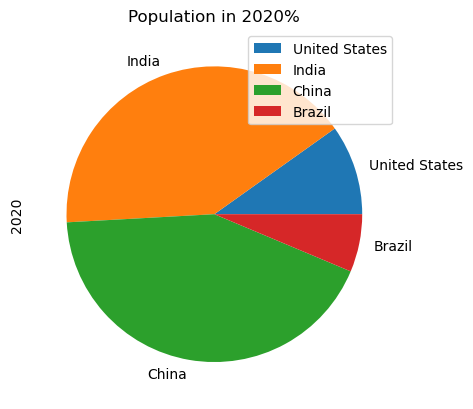

In [30]:
#making the plot
df_pivot_2020T.plot(kind='pie', y='2020', title='Population in 2020%')

5 Boxplot
5.1 single Boxplot

<Axes: >

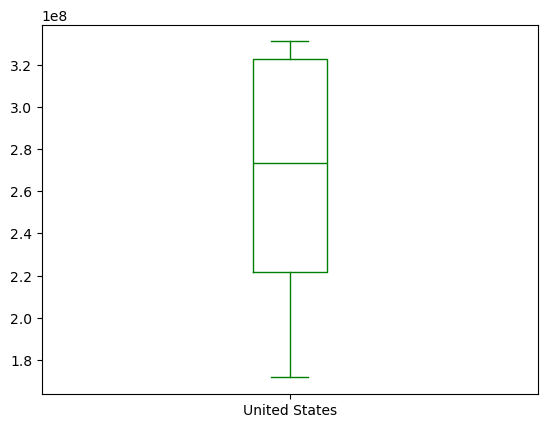

In [32]:
df_pivot_filter['United States'].plot(kind='box', color='green',
                                     y='Population')

5.2 Multiple Boxplot

<Axes: ylabel='Population'>

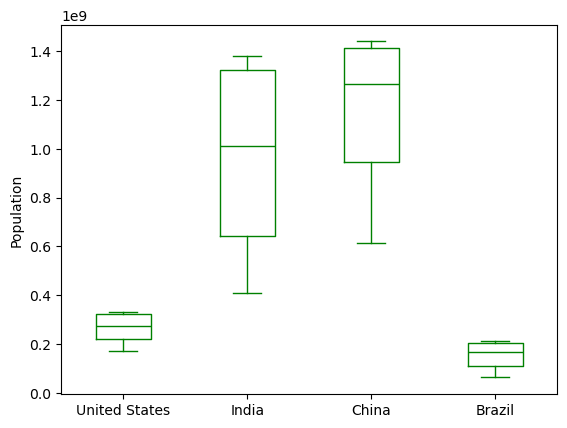

In [35]:
df_pivot_filter.plot(kind='box', color='green',
                                     ylabel='Population')

6 Histogram

<Axes: ylabel='Frequency'>

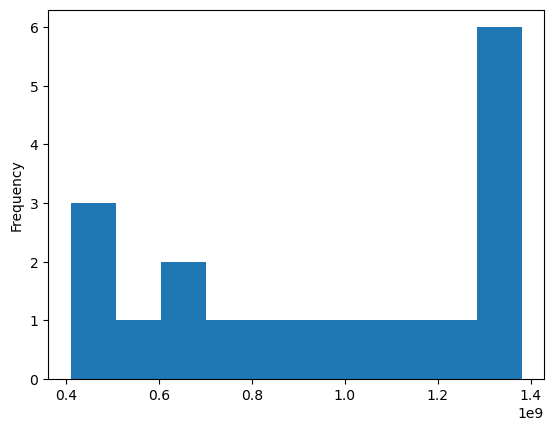

In [36]:
df_pivot_filter['India'].plot(kind='hist')

<Axes: ylabel='Frequency'>

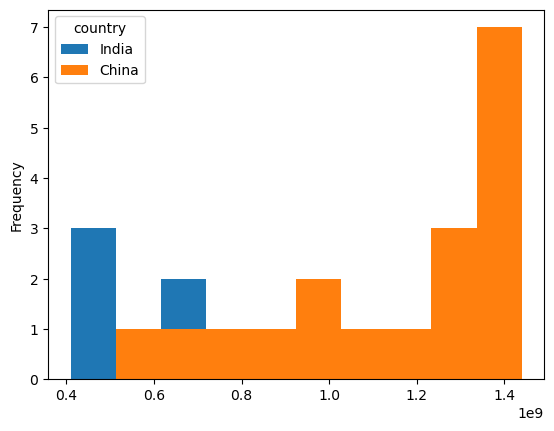

In [37]:
df_pivot_filter[['India','China']].plot(kind='hist')

7 ScatterPlot

In [41]:
#selecting a sample of raw data
df_sample1 = df[df['country'].isin(['India','China','Brazil'])]
df_sample1

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09
5,China,2015.0,1.406848e+09
6,China,2010.0,1.368811e+09
7,China,2005.0,1.330776e+09
8,China,2000.0,1.290551e+09
9,China,1995.0,1.240921e+09


<Axes: xlabel='year', ylabel='population'>

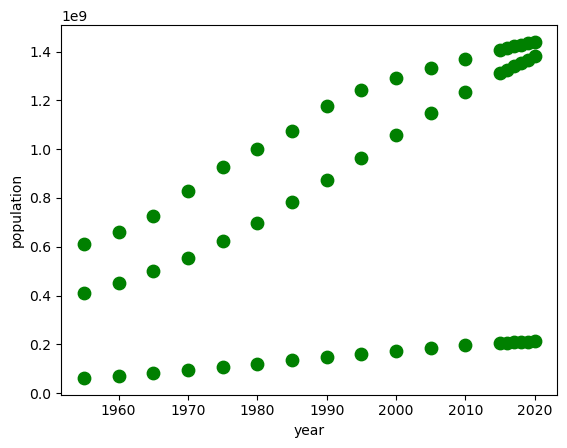

In [43]:
#creating the plot

df_sample1.plot(kind='scatter', x='year' , y= 'population', s=80, color= 'green')